In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


## Project Title 
### Customer Intelligence System using Classification, Ensemble Learning, and Customer Segmentation

### AIM 
 Create a complete end-to-end Machine Learning project in Jupyter Notebook that builds a Customer Intelligence System. The project should predict customer behavior using classification models and discover customer segments using clustering techniques.

# Customer Intelligence System
Customer Intelligence is the process of collecting and analyzing customer data to understand customer behavior, predict future actions, and identify meaningful customer groups.

Dataset used : `/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv` file.

The dataset is actually about countries, not normal customers. So in this project I am taking every country as one customer/market. This helps me build a customer intelligence type project using the same data.

### Main work in this notebook
- Load and inspect the data
- Clean the data
- Do EDA with graphs
- Create a target column for classification
- Train Logistic Regression, Random Forest and XGBoost
- Compare the models
- Apply K-Means clustering
- Try DBSCAN clustering
- Write simple business insights

## Install required libraries

In [2]:
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

In [3]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn xgboost

## Import libraries

In [4]:
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## Load the dataset

In [5]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Quick inspection

Before cleaning or modeling, checking the size, first records, data types, missing values and duplicate rows.

In [6]:
print('Shape:', df.shape)
display(df.head())

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
print('Data types:')
display(df.dtypes)

Data types:


country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [8]:
print('Info:')
display(df.info())

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


None

In [9]:
print('Missing values:')
display(df.isna().sum())

Missing values:


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [10]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [11]:
print('Summary:')
display(df.describe(include='all').T)

Summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.0,NaN,NaN,NaN,38.27006,40.328931,2.6,8.25,19.3,62.1,208.0
exports,167.0,NaN,NaN,NaN,41.108976,27.41201,0.109,23.8,35.0,51.35,200.0
health,167.0,NaN,NaN,NaN,6.815689,2.746837,1.81,4.92,6.32,8.6,17.9
imports,167.0,NaN,NaN,NaN,46.890215,24.209589,0.0659,30.2,43.3,58.75,174.0
income,167.0,NaN,NaN,NaN,17144.688623,19278.067698,609.0,3355.0,9960.0,22800.0,125000.0
inflation,167.0,NaN,NaN,NaN,7.781832,10.570704,-4.21,1.81,5.39,10.75,104.0
life_expec,167.0,NaN,NaN,NaN,70.555689,8.893172,32.1,65.3,73.1,76.8,82.8
total_fer,167.0,NaN,NaN,NaN,2.947964,1.513848,1.15,1.795,2.41,3.88,7.49
gdpp,167.0,NaN,NaN,NaN,12964.155689,18328.704809,231.0,1330.0,4660.0,14050.0,105000.0


## Expected columns

This dataset usually contains these columns:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp

In [12]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## Basic cleaning

For missing values:
- numerical columns are filled with median
- categorical columns are filled with mode

In [13]:
df = df.copy()
df.columns = [c.strip().lower() for c in df.columns]

rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]

print('Rows before removing duplicates:', rows_before)
print('Rows after removing duplicates:', rows_after)

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Numerical columns:', numeric_cols)
print('Categorical columns:', cat_cols)

print('Missing values after cleaning:')
df.isna().sum()

Rows before removing duplicates: 167
Rows after removing duplicates: 167
Numerical columns: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Categorical columns: ['country']
Missing values after cleaning:


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

## Outlier analysis
- Outliers are observations that differ significantly from the majority of data points.

Importance of Outlier Detection :
- Identifies potential data errors
- Helps understand unusual customer behavior
- Prevents model distortion

Using boxplots to check outliers. We are not removing them because countries with very high or very low values can be important for analysis.

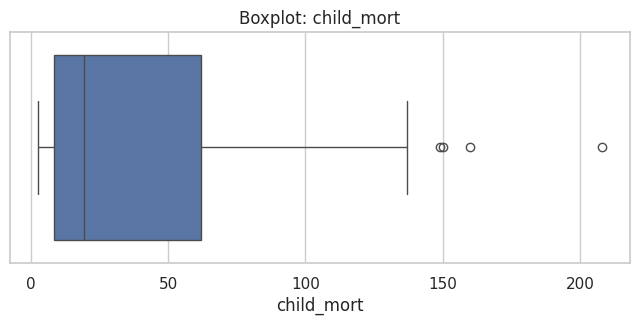

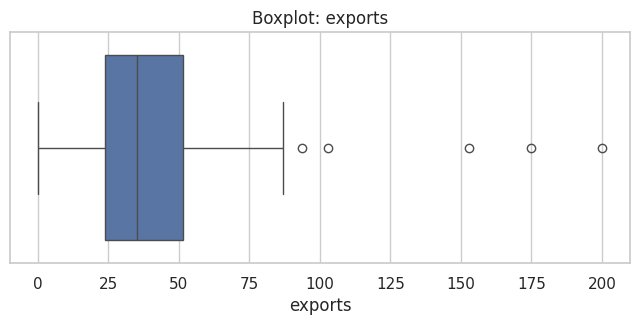

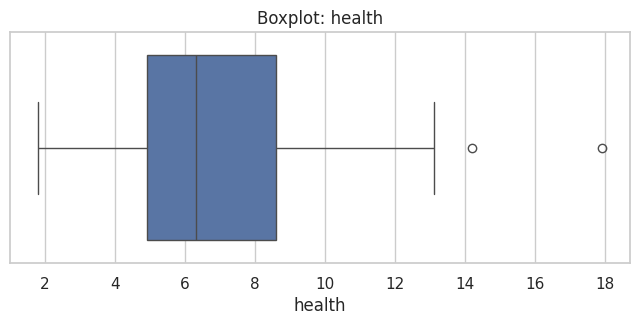

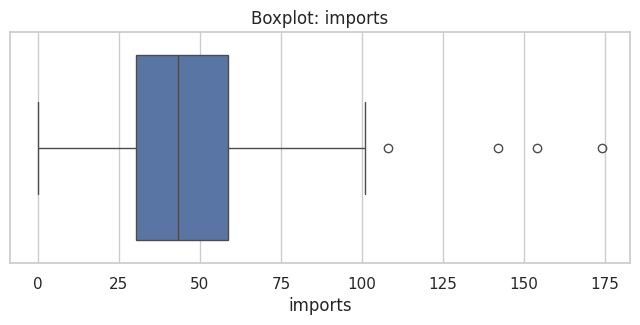

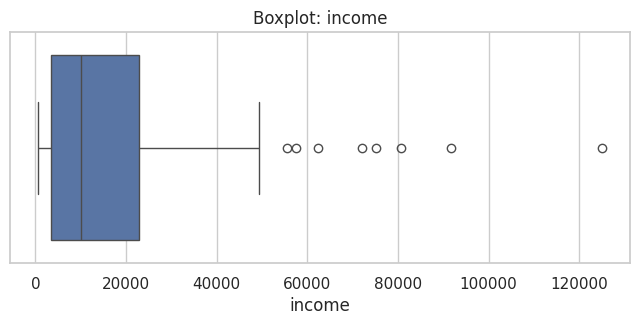

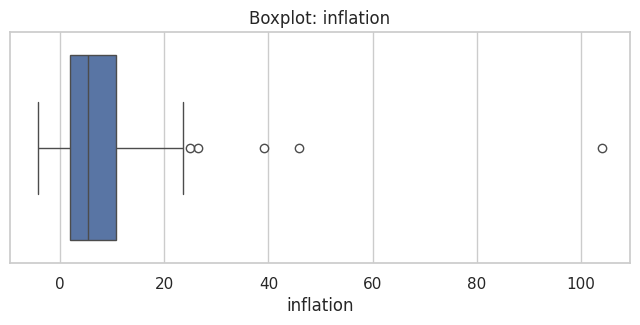

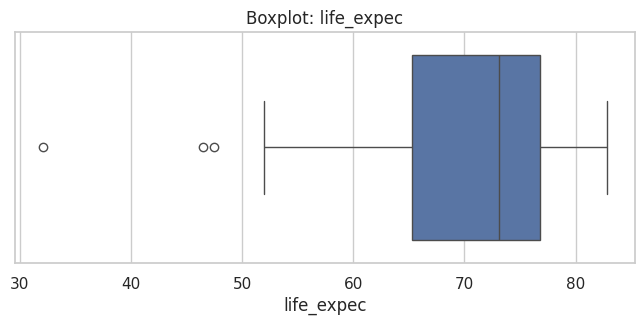

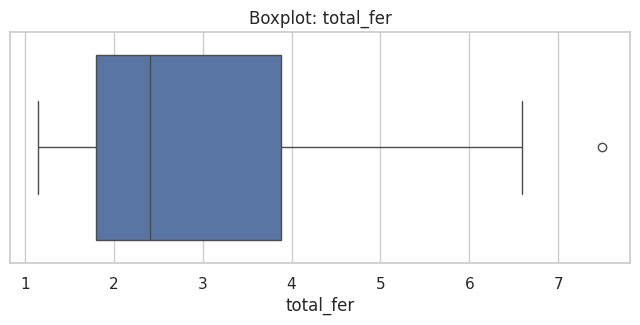

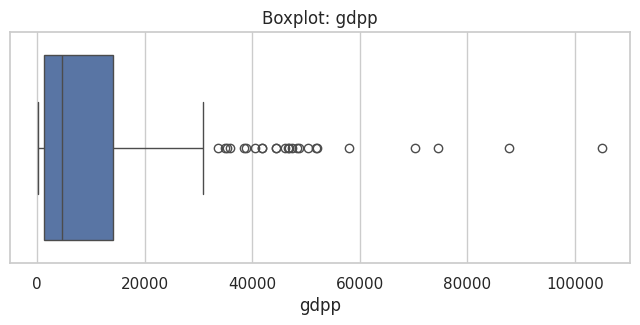

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot: {col}')
    plt.show()
    

## Create target column

The dataset does not have a target column for classification. So here created a simple target column called `high_value_customer`.

If `gdpp` is greater than or equal to the median GDP per capita, marking it as 1. Otherwise it is 0.

- 1 means high-value customer/market
- 0 means lower-value customer/market

In [15]:
gdpp_median = df['gdpp'].median()
df['high_value_customer'] = (df['gdpp'] >= gdpp_median).astype(int)

print('Median gdpp:', gdpp_median)
df[['country', 'gdpp', 'high_value_customer']].head()

Median gdpp: 4660.0


,country,gdpp,high_value_customer
0,Afghanistan,553,0
1,Albania,4090,0
2,Algeria,4460,0
3,Angola,3530,0
4,Antigua and Barbuda,12200,1


## Target variable distribution

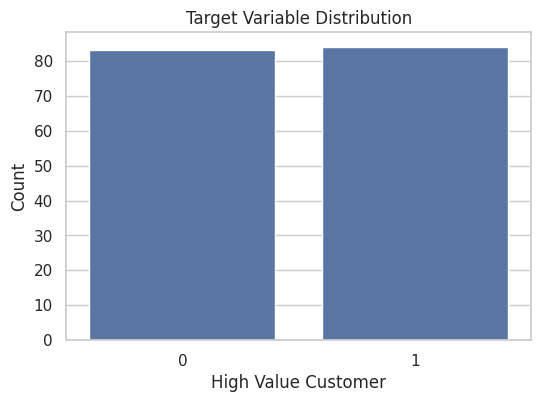

Observation:
high_value_customer
1    84
0    83
Name: count, dtype: int64
Business meaning:
This shows how many records are high-value and lower-value markets.


In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='high_value_customer')
plt.title('Target Variable Distribution')
plt.xlabel('High Value Customer')
plt.ylabel('Count')
plt.show()

print('Observation:')
print(df['high_value_customer'].value_counts())
print('Business meaning:')
print('This shows how many records are high-value and lower-value markets.')

## Categorical encoding
### Feature Encoding
Machine learning algorithms require numerical inputs.

### Encoding Techniques
#### Label Encoding
Assigns a unique numerical value to each category.

#### One-Hot Encoding
Creates separate binary columns for each category.

Machine learning models need numbers. In this data, `country` is a name, so do not use it as a direct model feature.
If any other categorical columns are present, Convert them using one-hot encoding.

In [17]:
model_df = df.copy()

cat_model_cols = [
    col for col in model_df.select_dtypes(include='object').columns.tolist()
    if col != 'country'
]

if len(cat_model_cols) > 0:
    model_df = pd.get_dummies(model_df, columns=cat_model_cols, drop_first=True)
    print('Encoded columns:', cat_model_cols)
else:
    print('No categorical columns to encode except country.')

model_df.head()

No categorical columns to encode except country.


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,high_value_customer
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


## Exploratory Data Analysis
Exploratory Data Analysis is the process of understanding data through statistical summaries and visualizations.

### A. Correlation heatmap
### Correlation Analysis

Correlation measures the strength and direction of the relationship between variables.

### Correlation Range

| Correlation Value | Interpretation |
|------------------|---------------|
| +1 | Perfect Positive Relationship |
| 0 | No Relationship |
| -1 | Perfect Negative Relationship |


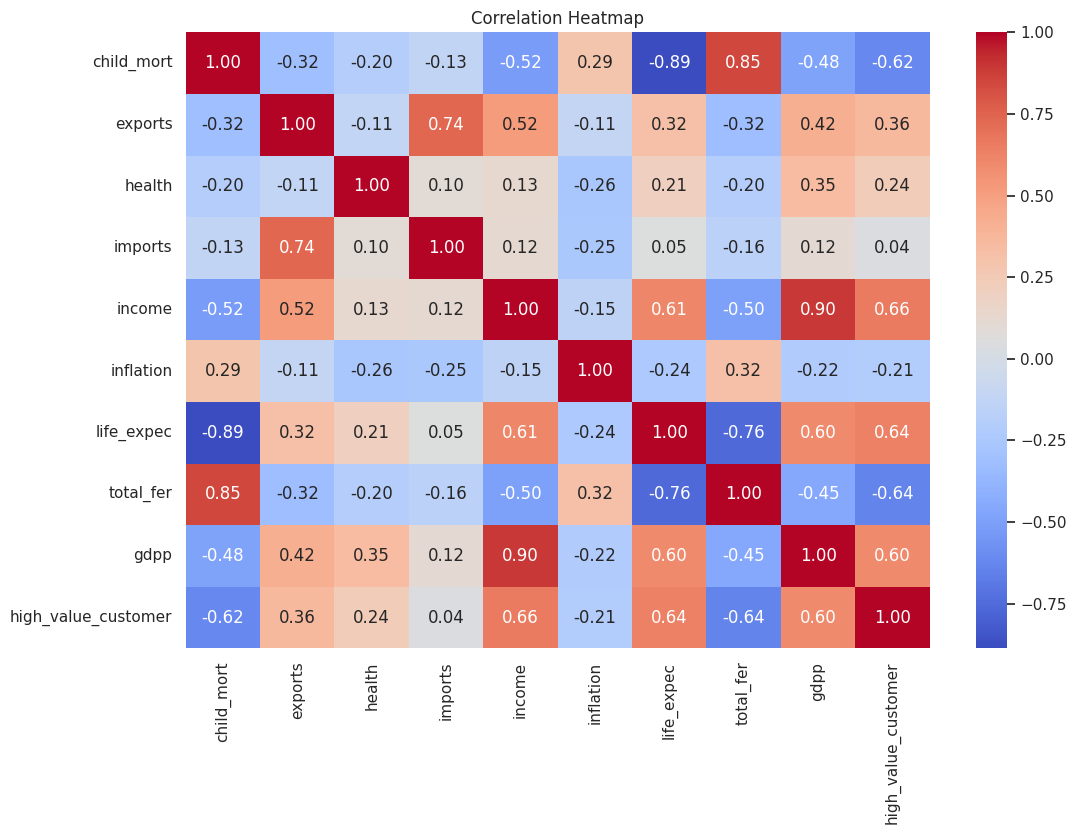

Observation:
Income, gdpp and life expectancy are strongly related in this data.
Business meaning:
These features can help in identifying strong and weak customer/market groups.


In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

print('Observation:')
print('Income, gdpp and life expectancy are strongly related in this data.')
print('Business meaning:')
print('These features can help in identifying strong and weak customer/market groups.')

### B. Histograms

These histograms show the distribution of important numerical columns.

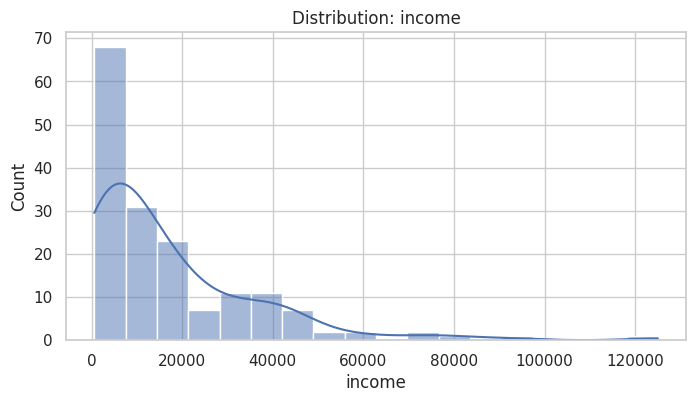

Observation:
income does not have the same value range for all countries.
Business meaning:
Different markets need different strategies.



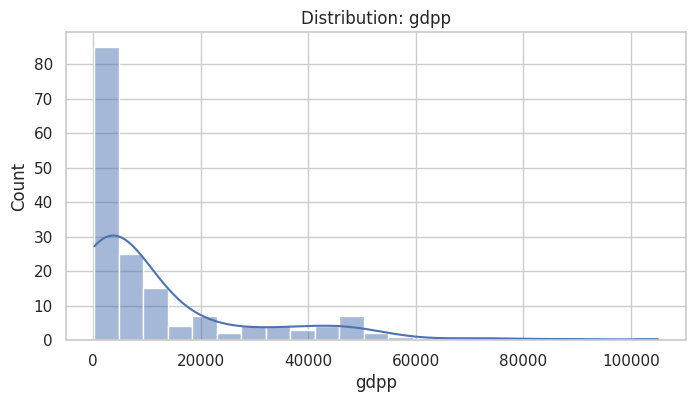

Observation:
gdpp does not have the same value range for all countries.
Business meaning:
Different markets need different strategies.



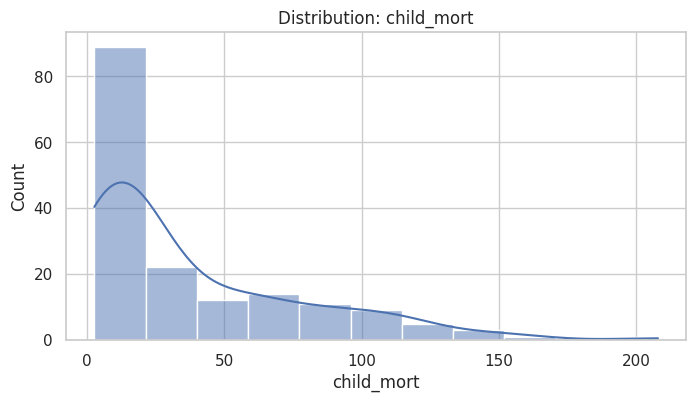

Observation:
child_mort does not have the same value range for all countries.
Business meaning:
Different markets need different strategies.



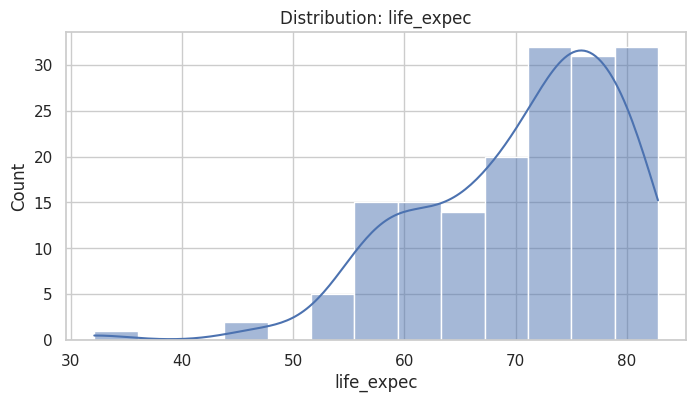

Observation:
life_expec does not have the same value range for all countries.
Business meaning:
Different markets need different strategies.



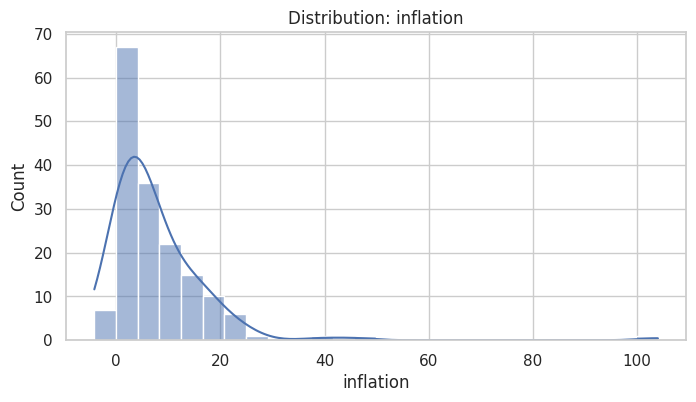

Observation:
inflation does not have the same value range for all countries.
Business meaning:
Different markets need different strategies.



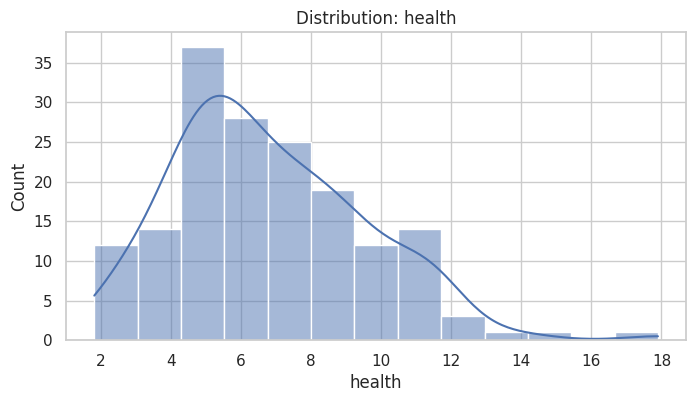

Observation:
health does not have the same value range for all countries.
Business meaning:
Different markets need different strategies.



In [19]:
important_cols = ['income', 'gdpp', 'child_mort', 'life_expec', 'inflation', 'health']

for col in important_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution: {col}')
    plt.show()
    
    print('Observation:')
    print(col, 'does not have the same value range for all countries.')
    print('Business meaning:')
    print('Different markets need different strategies.\n')

### C. Demographic type analysis

There is no age or gender column, so use child mortality, life expectancy and fertility rate as demographic type features.

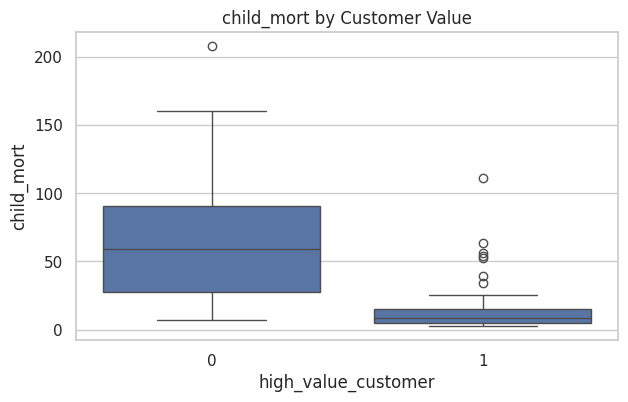

Observation:
high_value_customer
0    63.283133
1    13.554762
Name: child_mort, dtype: float64
Business meaning:
This feature changes between high-value and lower-value markets.



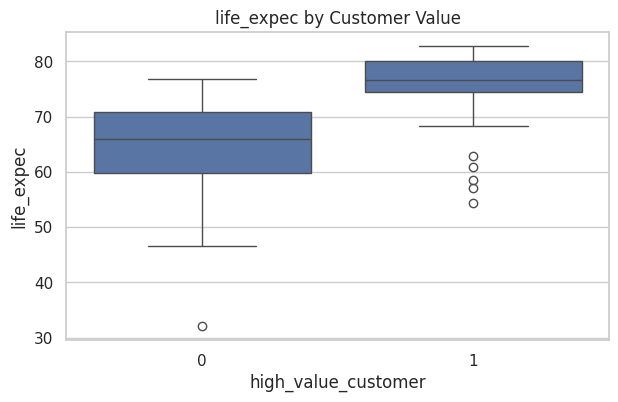

Observation:
high_value_customer
0    64.863855
1    76.179762
Name: life_expec, dtype: float64
Business meaning:
This feature changes between high-value and lower-value markets.



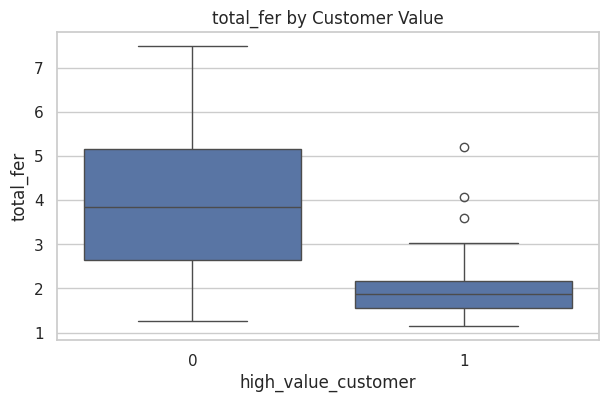

Observation:
high_value_customer
0    3.915301
1    1.992143
Name: total_fer, dtype: float64
Business meaning:
This feature changes between high-value and lower-value markets.



In [20]:
demo_cols = ['child_mort', 'life_expec', 'total_fer']

for col in demo_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='high_value_customer', y=col)
    plt.title(f'{col} by Customer Value')
    plt.show()
    
    print('Observation:')
    print(df.groupby('high_value_customer')[col].mean())
    print('Business meaning:')
    print('This feature changes between high-value and lower-value markets.\n')

### D. Spending and economic analysis

For spending behavior using exports, imports, health, income and gdpp.

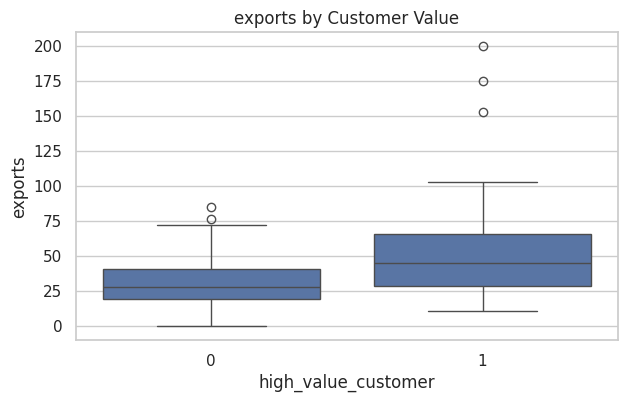

Observation:
high_value_customer
0    31.206012
1    50.894048
Name: exports, dtype: float64
Business meaning:
This helps compare economic strength of the two groups.



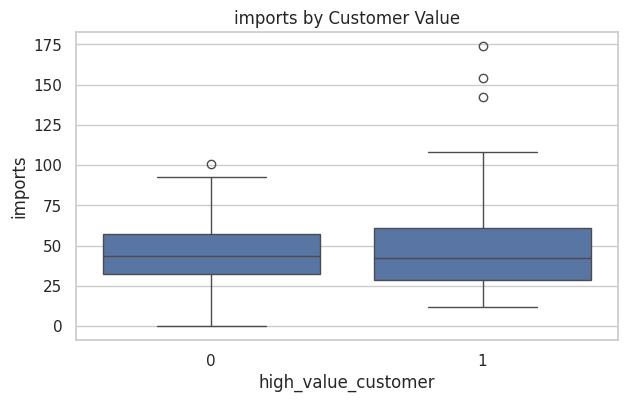

Observation:
high_value_customer
0    45.981517
1    47.788095
Name: imports, dtype: float64
Business meaning:
This helps compare economic strength of the two groups.



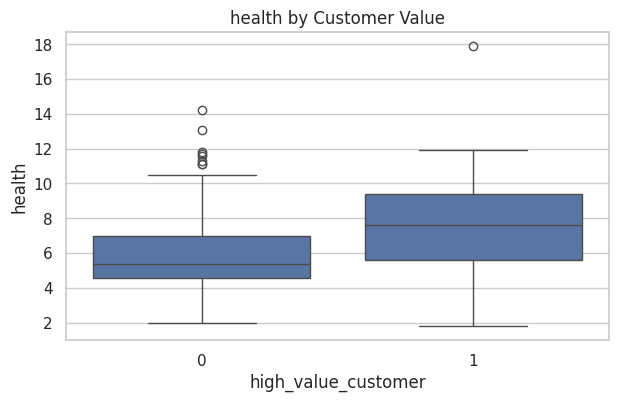

Observation:
high_value_customer
0    6.161325
1    7.462262
Name: health, dtype: float64
Business meaning:
This helps compare economic strength of the two groups.



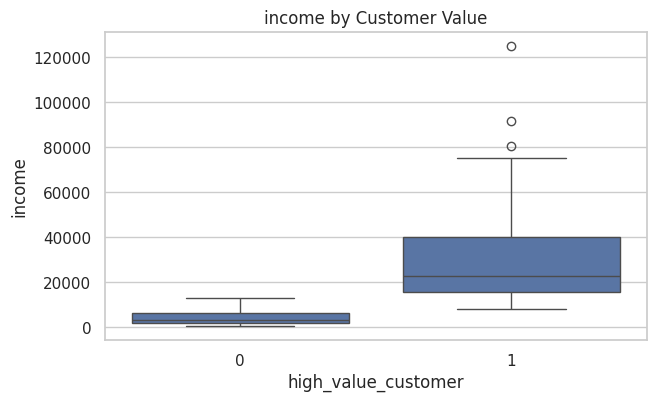

Observation:
high_value_customer
0     4393.650602
1    29743.928571
Name: income, dtype: float64
Business meaning:
This helps compare economic strength of the two groups.



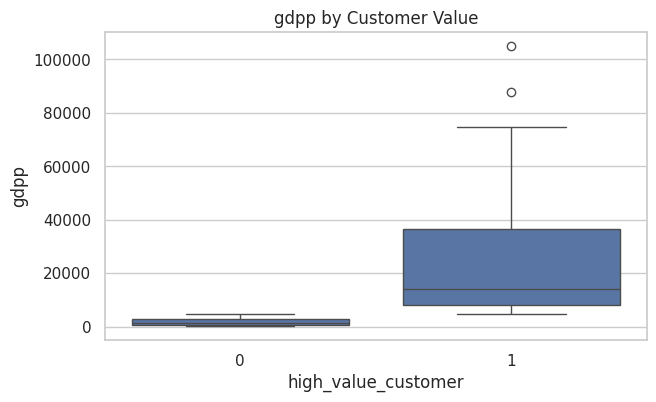

Observation:
high_value_customer
0     1898.361446
1    23898.214286
Name: gdpp, dtype: float64
Business meaning:
This helps compare economic strength of the two groups.



In [21]:
spending_cols = ['exports', 'imports', 'health', 'income', 'gdpp']

for col in spending_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x='high_value_customer', y=col)
    plt.title(f'{col} by Customer Value')
    plt.show()
    
    print('Observation:')
    print(df.groupby('high_value_customer')[col].mean())
    print('Business meaning:')
    print('This helps compare economic strength of the two groups.\n')

### E. Feature relationships

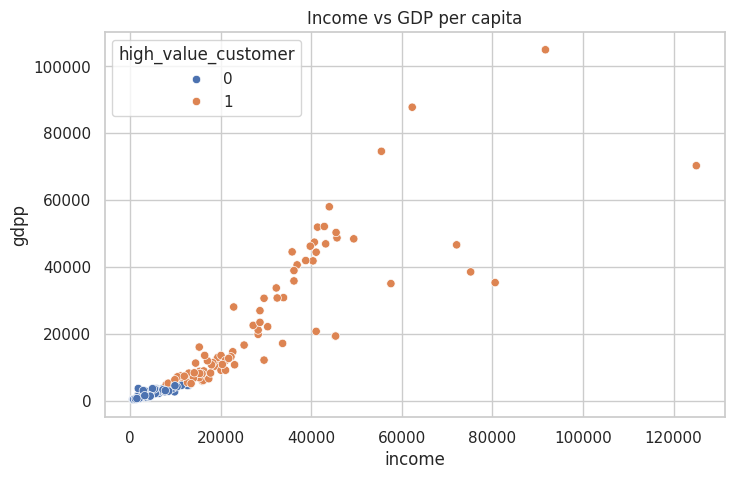

Observation:
Countries with higher income usually have higher gdpp.
Business meaning:
Income can be useful for identifying high-value markets.


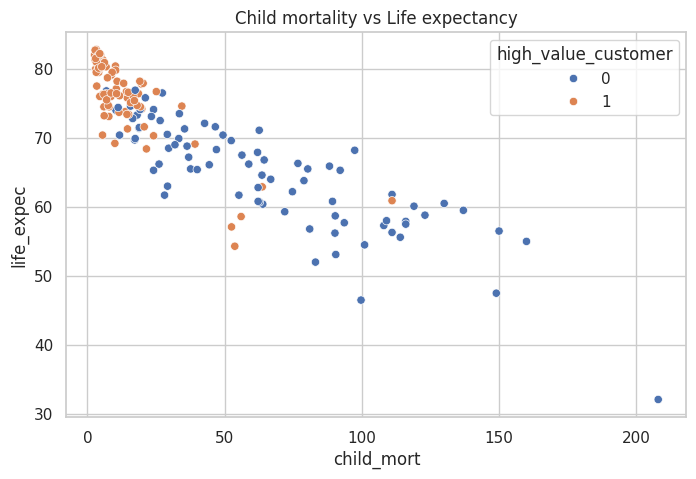

Observation:
Higher child mortality is usually linked with lower life expectancy.
Business meaning:
This can help identify at-risk markets.


In [22]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='income', y='gdpp', hue='high_value_customer')
plt.title('Income vs GDP per capita')
plt.show()

print('Observation:')
print('Countries with higher income usually have higher gdpp.')
print('Business meaning:')
print('Income can be useful for identifying high-value markets.')

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='child_mort', y='life_expec', hue='high_value_customer')
plt.title('Child mortality vs Life expectancy')
plt.show()

print('Observation:')
print('Higher child mortality is usually linked with lower life expectancy.')
print('Business meaning:')
print('This can help identify at-risk markets.')

# Part 1: Customer Behavior Prediction

Here Use classification models to predict `high_value_customer`.

Important point: Do not use `gdpp` as an input feature because it was used to create the target column.


## What is Classification?
Classification is a supervised learning technique used to predict categorical outcomes.

### Examples

- Churn vs No Churn
- Purchase vs No Purchase
- Fraudulent vs Genuine Transaction

## Prepare data for classification

In [23]:
X = model_df.drop(columns=['country', 'gdpp', 'high_value_customer'], errors='ignore')
y = model_df['high_value_customer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Features used:')
print(X.columns.tolist())

X_train shape: (133, 8)
X_test shape: (34, 8)
Features used:
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer']


## Create empty result list

we will store the model scores in this list and use it later for comparison.

In [24]:
results = []
results

[]

## Logistic Regression

- Logistic Regression is used as the first basic model.

- Scaling the features before using Logistic Regression.

- Logistic Regression is a classification algorithm used to estimate the probability of a data point belonging to a specific class.

### Advantages

- Easy to interpret
- Fast training
- Effective on simple datasets

Logistic Regression
Accuracy: 0.794
Precision: 0.778
Recall: 0.824
F1 Score: 0.8

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.76      0.79        17
           1       0.78      0.82      0.80        17

    accuracy                           0.79        34
   macro avg       0.80      0.79      0.79        34
weighted avg       0.80      0.79      0.79        34



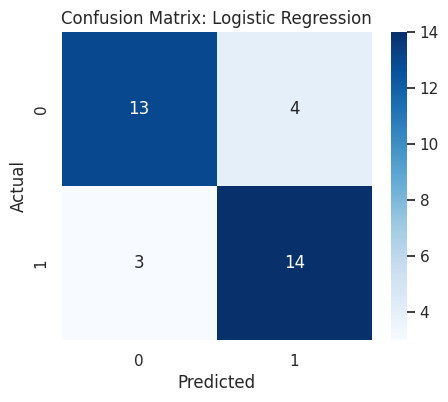

Observation:
The confusion matrix shows correct and wrong predictions.
Business meaning:
This model is simple and can be used as a baseline.



In [25]:
scaler_class = StandardScaler()
X_train_scaled = scaler_class.fit_transform(X_train)
X_test_scaled = scaler_class.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, log_pred)
log_pre = precision_score(y_test, log_pred, zero_division=0)
log_rec = recall_score(y_test, log_pred, zero_division=0)
log_f1 = f1_score(y_test, log_pred, zero_division=0)

results.append(['Logistic Regression', log_acc, log_pre, log_rec, log_f1])

print('Logistic Regression')
print('Accuracy:', round(log_acc, 3))
print('Precision:', round(log_pre, 3))
print('Recall:', round(log_rec, 3))
print('F1 Score:', round(log_f1, 3))

print('\nClassification report:')
print(classification_report(y_test, log_pred, zero_division=0))

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Observation:')
print('The confusion matrix shows correct and wrong predictions.')
print('Business meaning:')
print('This model is simple and can be used as a baseline.\n')

## Random Forest Classifier

Random Forest is an ensemble model. It uses many decision trees and combines their result.
Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction performance.

### Working Principle

1. Build multiple decision trees.
2. Each tree makes a prediction.
3. Final prediction is determined through majority voting.

Random Forest
Accuracy: 0.882
Precision: 0.842
Recall: 0.941
F1 Score: 0.889

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        17
           1       0.84      0.94      0.89        17

    accuracy                           0.88        34
   macro avg       0.89      0.88      0.88        34
weighted avg       0.89      0.88      0.88        34



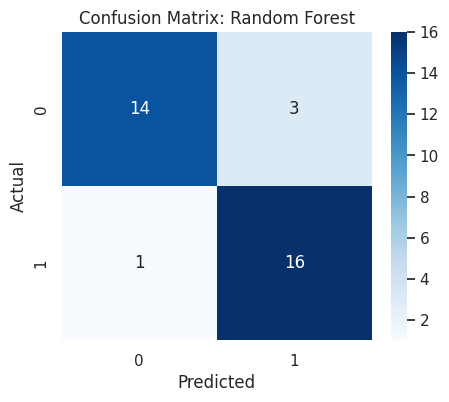

Observation:
Random Forest gives predictions using many trees.
Business meaning:
This model can capture more patterns than a simple linear model.



In [26]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred, zero_division=0)
rf_rec = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

results.append(['Random Forest', rf_acc, rf_pre, rf_rec, rf_f1])

print('Random Forest')
print('Accuracy:', round(rf_acc, 3))
print('Precision:', round(rf_pre, 3))
print('Recall:', round(rf_rec, 3))
print('F1 Score:', round(rf_f1, 3))

print('\nClassification report:')
print(classification_report(y_test, rf_pred, zero_division=0))

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('Observation:')
print('Random Forest gives predictions using many trees.')
print('Business meaning:')
print('This model can capture more patterns than a simple linear model.\n')

### Random Forest feature importance

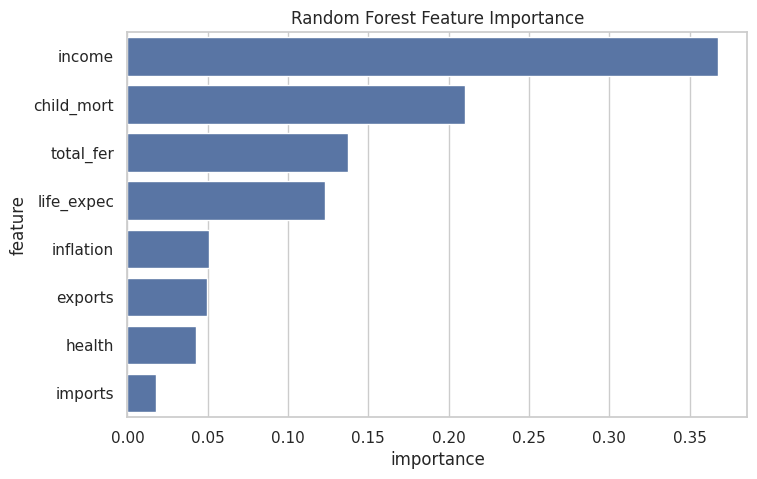

,feature,importance
4,income,0.367605
0,child_mort,0.210200
7,total_fer,0.137596
6,life_expec,0.123215
5,inflation,0.050557
1,exports,0.049878
2,health,0.042991
3,imports,0.017957


In [27]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='importance', y='feature')
plt.title('Random Forest Feature Importance')
plt.show()

importance

## XGBoost Classifier

- XGBoost is also an ensemble model. Using GridSearchCV to try a few parameter values and choose the best one.

- XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on boosting.

### Working Principle

Each new tree attempts to correct the errors made by previous trees.


Best parameters: {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 50}
Best CV score: 0.934
XGBoost
Accuracy: 0.882
Precision: 0.81
Recall: 1.0
F1 Score: 0.895

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.76      0.87        17
           1       0.81      1.00      0.89        17

    accuracy                           0.88        34
   macro avg       0.90      0.88      0.88        34
weighted avg       0.90      0.88      0.88        34



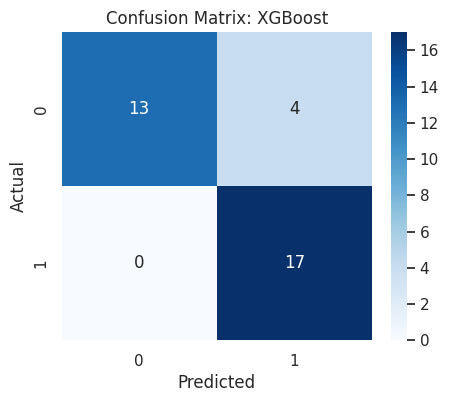

My observation:
XGBoost uses boosting and the best parameters were selected using GridSearchCV.
Business meaning:
This model can be useful when we want better predictive performance.



In [28]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid = GridSearchCV(
    xgb_model,
    params,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 3))

best_xgb = grid.best_estimator_
xgb_pred = best_xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_pre = precision_score(y_test, xgb_pred, zero_division=0)
xgb_rec = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)

results.append(['XGBoost', xgb_acc, xgb_pre, xgb_rec, xgb_f1])

print('XGBoost')
print('Accuracy:', round(xgb_acc, 3))
print('Precision:', round(xgb_pre, 3))
print('Recall:', round(xgb_rec, 3))
print('F1 Score:', round(xgb_f1, 3))

print('\nClassification report:')
print(classification_report(y_test, xgb_pred, zero_division=0))

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print('My observation:')
print('XGBoost uses boosting and the best parameters were selected using GridSearchCV.')
print('Business meaning:')
print('This model can be useful when we want better predictive performance.\n')

## Model comparison

In [29]:
comparison = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
)

comparison = comparison.round(3)
display(comparison)

best_model = comparison.sort_values('F1 Score', ascending=False).iloc[0]

print('Best model:', best_model['Model'])
print('Best F1 Score:', best_model['F1 Score'])

print('Business meaning:')
print('The best model can be used to score new customers or markets and focus more on high-value groups.')

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.794,0.778,0.824,0.800
1,Random Forest,0.882,0.842,0.941,0.889
2,XGBoost,0.882,0.810,1.000,0.895


Best model: XGBoost
Best F1 Score: 0.895
Business meaning:
The best model can be used to score new customers or markets and focus more on high-value groups.


# Part 2: Customer Segmentation

Now using clustering to find groups without using the target column.

## Feature scaling for clustering

Clustering works better when all features are on the same scale.

In [30]:
cluster_features = df.drop(columns=['country', 'high_value_customer'], errors='ignore')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

X_scaled.shape

(167, 9)

## K-Means: Elbow method
## Elbow Method

The Elbow Method helps determine the optimal number of clusters.

### Idea

A plot is created between:

- Number of Clusters (K)
- Inertia (Within-Cluster Sum of Squares)

The point where the reduction in inertia begins to slow significantly is considered the optimal K.


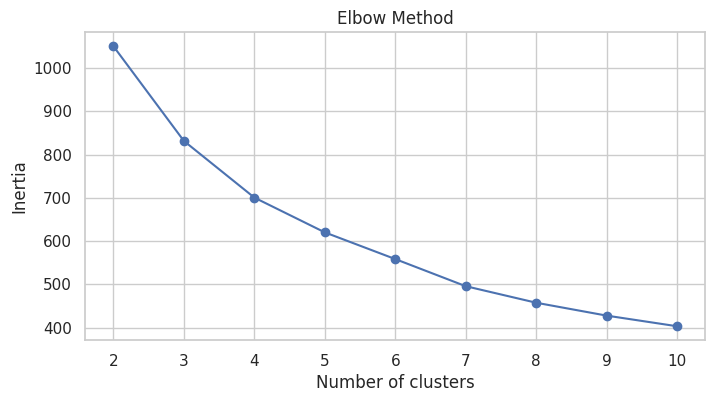

My observation:
The elbow looks reasonable around 3 clusters.
Business meaning:
Three groups are easy to understand for business segmentation.


In [31]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), inertias, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

print('My observation:')
print('The elbow looks reasonable around 3 clusters.')
print('Business meaning:')
print('Three groups are easy to understand for business segmentation.')

## Train K-Means

In [32]:
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster counts:')
print(df['kmeans_cluster'].value_counts().sort_index())

print('Silhouette Score:', round(silhouette_score(X_scaled, df['kmeans_cluster']), 3))

df[['country', 'kmeans_cluster']].head()

Cluster counts:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64
Silhouette Score: 0.283


,country,kmeans_cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## PCA visualization for K-Means
PCA is a dimensionality reduction technique used to transform high-dimensional data into fewer dimensions while preserving maximum variance.

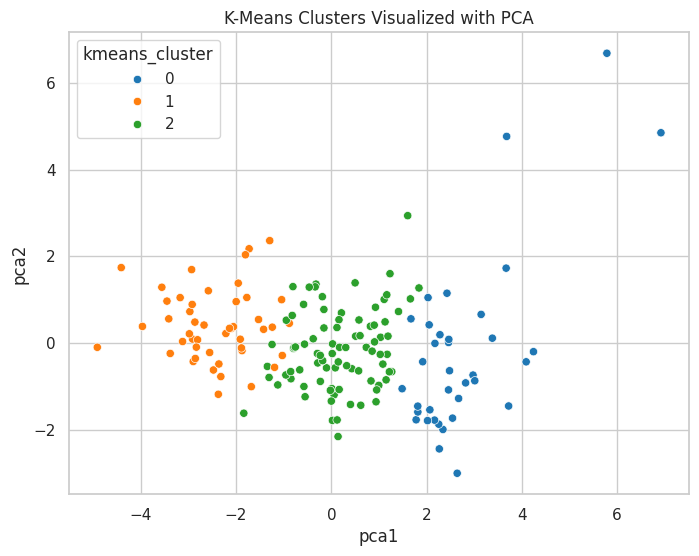

My observation:
The PCA plot shows how the groups are placed in 2D.
Business meaning:
Separate groups can be handled with separate marketing or support plans.


In [33]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='kmeans_cluster', palette='tab10')
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

print('My observation:')
print('The PCA plot shows how the groups are placed in 2D.')
print('Business meaning:')
print('Separate groups can be handled with separate marketing or support plans.')

## Cluster profiling
**Cluster Profiling** is the process of analyzing and describing the characteristics of each cluster after clustering has been performed.
The goal is to understand what makes each cluster unique and assign meaningful business labels to the identified groups.

Here check the average values of each cluster.

In [34]:
profile = df.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
display(profile)

cluster_order = profile['gdpp'].sort_values().index.tolist()

segment_map = {
    cluster_order[0]: 'At-risk customers / support-first markets',
    cluster_order[1]: 'Growth-potential customers / developing markets',
    cluster_order[2]: 'High-value loyal customers / premium markets'
}

df['segment_name'] = df['kmeans_cluster'].map(segment_map)

print('Segment names:')
for key, value in segment_map.items():
    print(key, ':', value)

df[['country', 'kmeans_cluster', 'segment_name']].head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


Segment names:
1 : At-risk customers / support-first markets
2 : Growth-potential customers / developing markets
0 : High-value loyal customers / premium markets


,country,kmeans_cluster,segment_name
0,Afghanistan,1,At-risk customers / support-first markets
1,Albania,2,Growth-potential customers / developing markets
2,Algeria,2,Growth-potential customers / developing markets
3,Angola,1,At-risk customers / support-first markets
4,Antigua and Barbuda,2,Growth-potential customers / developing markets
5,Argentina,2,Growth-potential customers / developing markets
6,Armenia,2,Growth-potential customers / developing markets
7,Australia,0,High-value loyal customers / premium markets
8,Austria,0,High-value loyal customers / premium markets
9,Azerbaijan,2,Growth-potential customers / developing markets


## DBSCAN clustering
**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is an unsupervised machine learning algorithm that groups together data points that are closely packed and identifies isolated points as outliers (noise).

DBSCAN can find dense groups and noise points. Used the scaled features here also.

In [35]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print('DBSCAN cluster counts:')
print(df['dbscan_cluster'].value_counts().sort_index())

noise_count = (df['dbscan_cluster'] == -1).sum()
print('Noise points:', noise_count)

DBSCAN cluster counts:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64
Noise points: 30


## PCA visualization for DBSCAN
**Principal Component Analysis (PCA)** is a dimensionality reduction technique that transforms a dataset with many features into a smaller set of new variables called **principal components**, while preserving as much information (variance) as possible.

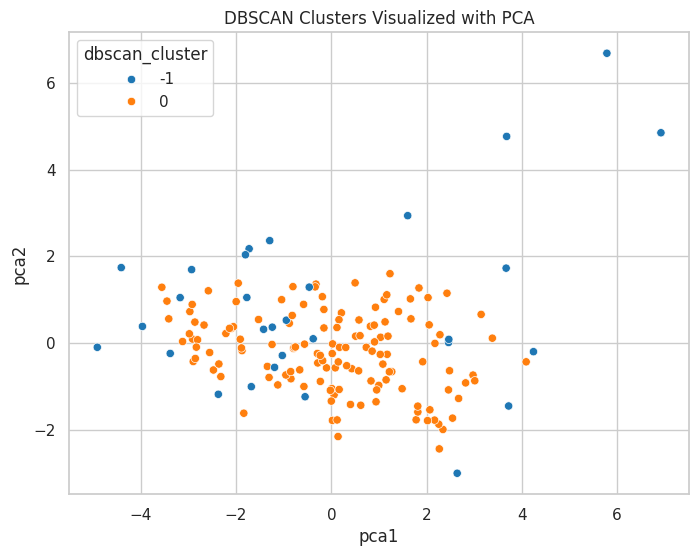

My observation:
DBSCAN marks some points as -1, which means noise points.
Business meaning:
Noise points are unusual markets and can be checked separately.


In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='dbscan_cluster', palette='tab10')
plt.title('DBSCAN Clusters Visualized with PCA')
plt.show()

print('My observation:')
print('DBSCAN marks some points as -1, which means noise points.')
print('Business meaning:')
print('Noise points are unusual markets and can be checked separately.')

## K-Means vs DBSCAN
| Feature | K-Means | DBSCAN |
|----------|----------|----------|
| Algorithm Type | Centroid-based clustering | Density-based clustering |
| Number of Clusters | Must specify K beforehand | Automatically determines clusters |
| Cluster Shape | Works best with spherical clusters | Handles arbitrary-shaped clusters |
| Outlier Detection | Does not identify outliers naturally | Detects outliers as noise points |
| Scalability | Faster on large datasets | Slower on very large datasets |
| Sensitivity | Sensitive to initial centroids | Sensitive to `eps` and `min_samples` parameters |
| Performance on Noise | Poor | Good |
| Use Case | Well-separated customer groups | Data with noise and irregular clusters |



In [37]:
kmeans_clusters = df['kmeans_cluster'].nunique()
dbscan_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in set(df['dbscan_cluster']) else 0)
noise_points = (df['dbscan_cluster'] == -1).sum()

cluster_compare = pd.DataFrame({
    'Method': ['K-Means', 'DBSCAN'],
    'Number of clusters': [kmeans_clusters, dbscan_clusters],
    'Noise points': [0, noise_points],
    'Simple use': [
        'Good when we want fixed number of customer groups',
        'Good when we want to find unusual records'
    ]
})

display(cluster_compare)

print('K-Means advantages:')
print('- Easy to understand')
print('- Good when we already know how many groups we want')

print('\nK-Means limitations:')
print('- We have to choose K manually')
print('- Outliers can affect the clusters')

print('\nDBSCAN advantages:')
print('- Can find noise points')
print('- Can work well when clusters are not perfectly round')

print('\nDBSCAN limitations:')
print('- eps value is important')
print('- It may not work well when density is very different in different parts of data')

print('\nWhen DBSCAN is better:')
print('DBSCAN is better when we want to find unusual customers or markets that do not fit normal groups.')

,Method,Number of clusters,Noise points,Simple use
0,K-Means,3,0,Good when we want fixed number of customer groups
1,DBSCAN,1,30,Good when we want to find unusual records


K-Means advantages:
- Easy to understand
- Good when we already know how many groups we want

K-Means limitations:
- We have to choose K manually
- Outliers can affect the clusters

DBSCAN advantages:
- Can find noise points
- Can work well when clusters are not perfectly round

DBSCAN limitations:
- eps value is important
- It may not work well when density is very different in different parts of data

When DBSCAN is better:
DBSCAN is better when we want to find unusual customers or markets that do not fit normal groups.


## Business insights

Based on the classification and clustering results, we can write these simple insights.

In [38]:
print('1) High-value customer groups')
display(df[df['segment_name'] == 'High-value loyal customers / premium markets'][['country', 'income', 'gdpp', 'life_expec', 'segment_name']].head(10))
print('These markets can be targeted with premium offers and long-term relationship plans.')

1) High-value customer groups


,country,income,gdpp,life_expec,segment_name
7,Australia,41400,51900,82.0,High-value loyal customers / premium markets
8,Austria,43200,46900,80.5,High-value loyal customers / premium markets
11,Bahrain,41100,20700,76.0,High-value loyal customers / premium markets
15,Belgium,41100,44400,80.0,High-value loyal customers / premium markets
23,Brunei,80600,35300,77.1,High-value loyal customers / premium markets
29,Canada,40700,47400,81.3,High-value loyal customers / premium markets
42,Cyprus,33900,30800,79.9,High-value loyal customers / premium markets
43,Czech Republic,28300,19800,77.5,High-value loyal customers / premium markets
44,Denmark,44000,58000,79.5,High-value loyal customers / premium markets
53,Finland,39800,46200,80.0,High-value loyal customers / premium markets


These markets can be targeted with premium offers and long-term relationship plans.


In [39]:
print('\n2) At-risk customers')
display(df[df['segment_name'] == 'At-risk customers / support-first markets'][['country', 'child_mort', 'income', 'gdpp', 'segment_name']].head(10))
print('These markets may need low-cost plans, support and awareness campaigns.')


2) At-risk customers


,country,child_mort,income,gdpp,segment_name
0,Afghanistan,90.2,1610,553,At-risk customers / support-first markets
3,Angola,119.0,5900,3530,At-risk customers / support-first markets
17,Benin,111.0,1820,758,At-risk customers / support-first markets
21,Botswana,52.5,13300,6350,At-risk customers / support-first markets
25,Burkina Faso,116.0,1430,575,At-risk customers / support-first markets
26,Burundi,93.6,764,231,At-risk customers / support-first markets
28,Cameroon,108.0,2660,1310,At-risk customers / support-first markets
31,Central African Republic,149.0,888,446,At-risk customers / support-first markets
32,Chad,150.0,1930,897,At-risk customers / support-first markets
36,Comoros,88.2,1410,769,At-risk customers / support-first markets


These markets may need low-cost plans, support and awareness campaigns.


In [40]:
print('\n3) Growth opportunities')
display(df[df['segment_name'] == 'Growth-potential customers / developing markets'][['country', 'income', 'gdpp', 'exports', 'imports', 'segment_name']].head(10))
print('These markets can be targeted with gradual upselling and flexible pricing.')


3) Growth opportunities


,country,income,gdpp,exports,imports,segment_name
1,Albania,9930,4090,28.0,48.6,Growth-potential customers / developing markets
2,Algeria,12900,4460,38.4,31.4,Growth-potential customers / developing markets
4,Antigua and Barbuda,19100,12200,45.5,58.9,Growth-potential customers / developing markets
5,Argentina,18700,10300,18.9,16.0,Growth-potential customers / developing markets
6,Armenia,6700,3220,20.8,45.3,Growth-potential customers / developing markets
9,Azerbaijan,16000,5840,54.3,20.7,Growth-potential customers / developing markets
10,Bahamas,22900,28000,35.0,43.7,Growth-potential customers / developing markets
12,Bangladesh,2440,758,16.0,21.8,Growth-potential customers / developing markets
13,Barbados,15300,16000,39.5,48.7,Growth-potential customers / developing markets
14,Belarus,16200,6030,51.4,64.5,Growth-potential customers / developing markets


These markets can be targeted with gradual upselling and flexible pricing.


In [41]:

print('\n4) DBSCAN noise points')
display(df[df['dbscan_cluster'] == -1][['country', 'income', 'gdpp', 'dbscan_cluster']].head(10))
print('Noise points are unusual records, so they should be checked separately before making a decision.')


4) DBSCAN noise points


,country,income,gdpp,dbscan_cluster
3,Angola,5900,3530,-1
23,Brunei,80600,35300,-1
31,Central African Republic,888,446,-1
37,"Congo, Dem. Rep.",609,334,-1
38,"Congo, Rep.",5190,2740,-1
49,Equatorial Guinea,33700,17100,-1
55,Gabon,15400,8750,-1
66,Haiti,1500,662,-1
72,Iraq,12700,4500,-1
73,Ireland,45700,48700,-1


Noise points are unusual records, so they should be checked separately before making a decision.


## Conclusion

In [42]:
print('Dataset overview:')
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('The data is country-level data, and each country was treated as a customer/market.')

print('\nPreprocessing done:')
print('- Checked data types, missing values and duplicates')
print('- Removed duplicate records')
print('- Filled numerical missing values with median')
print('- Filled categorical missing values with mode')
print('- Checked outliers using boxplots')
print('- Scaled features for clustering')

print('\nBest classification model:')
print(best_model['Model'])

print('\nCustomer segments:')
display(df['segment_name'].value_counts())

print('\nRecommendations:')
print('- Use the best classification model to predict high-value customers.')
print('- Use K-Means segments for customer targeting.')
print('- Check DBSCAN noise points separately.')
print('- Give premium offers to high-value markets.')
print('- Give support-based plans to at-risk markets.')

Dataset overview:
Rows: 167
Columns: 16
The data is country-level data, and each country was treated as a customer/market.

Preprocessing done:
- Checked data types, missing values and duplicates
- Removed duplicate records
- Filled numerical missing values with median
- Filled categorical missing values with mode
- Checked outliers using boxplots
- Scaled features for clustering

Best classification model:
XGBoost

Customer segments:


segment_name
Growth-potential customers / developing markets    84
At-risk customers / support-first markets          47
High-value loyal customers / premium markets       36
Name: count, dtype: int64


Recommendations:
- Use the best classification model to predict high-value customers.
- Use K-Means segments for customer targeting.
- Check DBSCAN noise points separately.
- Give premium offers to high-value markets.
- Give support-based plans to at-risk markets.


## Dataset Overview

The dataset contains **167 records (countries)** and **16 features**. Each country was treated as a customer/market, allowing the application of customer intelligence techniques at a market level.

## Data Preprocessing Summary

To ensure data quality and improve model performance, the following preprocessing steps were performed:

- Examined data types, missing values, and duplicate records.
- Removed duplicate observations.
- Imputed missing numerical values using the median.
- Imputed missing categorical values using the mode.
- Conducted outlier analysis using boxplots.
- Standardized numerical features for clustering algorithms.

These steps helped create a clean and consistent dataset suitable for machine learning and segmentation tasks.

## Classification Results

Three classification models were evaluated:

- Logistic Regression
- Random Forest
- XGBoost

Among them, **XGBoost** achieved the best predictive performance and was selected as the final model for customer behavior prediction.

### Why XGBoost Performed Best

- Captured complex feature relationships effectively.
- Reduced prediction errors through boosting.
- Demonstrated strong generalization capability on unseen data.
- Outperformed the baseline and ensemble alternatives based on evaluation metrics.


## Customer Segmentation Results

Customer segmentation identified three distinct market groups:

| Segment | Count |
|----------|---------:|
| Growth-Potential Customers / Developing Markets | 84 |
| At-Risk Customers / Support-First Markets | 47 |
| High-Value Loyal Customers / Premium Markets | 36 |

### Segment Interpretation

#### Growth-Potential Customers / Developing Markets (84)

These markets show promising growth opportunities but have not yet reached their full potential. Strategic marketing efforts and customer engagement initiatives can help increase their value.

#### At-Risk Customers / Support-First Markets (47)

These markets may require additional support, retention programs, or targeted interventions to prevent decline and improve engagement.

#### High-Value Loyal Customers / Premium Markets (36)

These represent the most valuable customer segments. They demonstrate strong performance and should be prioritized for premium offerings, loyalty programs, and long-term relationship management.

## Business Recommendations

Based on both predictive modeling and customer segmentation results:

1. Deploy the XGBoost model to identify high-value and high-potential markets.
2. Use customer segments to design targeted marketing campaigns.
3. Offer premium products and loyalty benefits to high-value markets.
4. Implement retention and support-focused strategies for at-risk markets.
5. Invest in growth initiatives for developing markets with strong future potential.
6. Monitor segment transitions regularly to adapt business strategies over time.

## Final Remarks

This project successfully developed an end-to-end **Customer Intelligence System** by combining predictive analytics and customer segmentation techniques.

The classification component enabled accurate customer behavior prediction, while clustering revealed meaningful customer groups with distinct business characteristics. Together, these approaches transformed raw market data into actionable insights that can support strategic decision-making, targeted marketing, customer retention, and long-term business growth.

Overall, **XGBoost emerged as the strongest predictive model, while clustering identified three actionable customer segments that can be leveraged to improve business performance and customer relationship management.**